In [1]:
import json
import torch
from datasets import Dataset
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template, train_on_responses_only
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import classification_report, f1_score, accuracy_score
from tqdm import tqdm

# ============================================================
# 1. CẤU HÌNH
# ============================================================
MODEL_NAME     = "unsloth/gemma-3-4b-it"   # dùng Gemma3 API mới
MAX_SEQ_LENGTH = 1536
MAX_NEW_TOKENS = 8


OUTPUT_DIR     = "output/outputs_gemma_fact"
BEST_MODEL_DIR = "output/gemma_fact_checking_lora"
LABEL_LIST     = ["SUPPORTED", "REFUTED", "NEI"]

# ============================================================
# 2. MODEL & TOKENIZER — dùng FastModel (API mới)
# ============================================================
print("🚀 Đang khởi tạo model...")
model, tokenizer = FastModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,
    load_in_8bit   = False,
    full_finetuning = False,
)

model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r            = 16,
    lora_alpha   = 32,
    lora_dropout = 0,
    bias         = "none",
    random_state = 3407,
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
🚀 Đang khởi tạo model...
==((====))==  Unsloth 2026.5.5: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.691 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.56G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

In [3]:
TRAIN_PATH     = "dataset/train.json"
VAL_PATH       = "dataset/val.json"
TEST_PATH      = "dataset/test.json"

In [4]:

# ============================================================
# 3. TOKENIZER — wrap bằng get_chat_template (bắt buộc)
# ============================================================
tokenizer = get_chat_template(tokenizer, chat_template="gemma-3")

# ============================================================
# 4. FORMAT DATA — giữ "text" dạng string như hướng dẫn
# ============================================================
INSTRUCTION = (
    "Bạn là một trợ lý AI kiểm chứng thông tin chuẩn xác. "
    "Hãy đọc các đoạn văn bối cảnh và đưa ra nhãn phân loại cho câu khẳng định. "
    "Chỉ trả về đúng một từ duy nhất, không giải thích, không dấu câu: "
    "SUPPORTED, REFUTED, hoặc NEI."
)

def build_user_message(claim: str, contexts: list) -> str:
    ctx_text = "\n".join([f"Đoạn văn {i+1}: {c}" for i, c in enumerate(contexts)])
    return (
        f"{INSTRUCTION}\n\n"
        f"[Bối cảnh]:\n{ctx_text}\n\n"
        f"[Khẳng định]: {claim}\n\n"
        f"[Nhãn phân loại]:"
    )

def format_for_training(examples: dict) -> dict:
    """Batched map — trả về text string như hướng dẫn Unsloth."""
    texts = []
    for claim, contexts, label in zip(
        examples["claim"], examples["contexts"], examples["label"]
    ):
        messages = [
            {"role": "user",      "content": build_user_message(claim, contexts)},
            {"role": "assistant", "content": label},
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        ).removeprefix("<bos>")   # như hướng dẫn — processor sẽ tự thêm <bos>
        texts.append(text)
    return {"text": texts}

# ============================================================
# 5. LOAD VÀ MAP DATA
# ============================================================
print("📦 Đang nạp dữ liệu...")
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_raw = json.load(f)
with open(VAL_PATH, "r", encoding="utf-8") as f:
    val_raw = json.load(f)
with open(TEST_PATH, "r", encoding="utf-8") as f:
    test_raw = json.load(f)

train_dataset_raw = Dataset.from_list(train_raw)
val_dataset_raw   = Dataset.from_list(val_raw)

col_names = [c for c in train_dataset_raw.column_names if c != "text"]

train_dataset = train_dataset_raw.map(format_for_training, batched=True, remove_columns=col_names)
val_dataset   = val_dataset_raw.map(format_for_training,   batched=True, remove_columns=col_names)

assert "text" in train_dataset.column_names
print(f"  ✅ Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_raw)} mẫu")

# ============================================================
# 6. TRAINING + train_on_responses_only
# ============================================================
print("\n🏋️  Bắt đầu training...")

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    args = SFTConfig(
        dataset_text_field          = "text",  # hoạt động đúng nhờ get_chat_template
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps                = 50,
        num_train_epochs            = 3,
        learning_rate               = 2e-4,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 10,
        eval_strategy               = "steps",
        eval_steps                  = 50,
        save_strategy               = "steps",
        save_steps                  = 50,
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        save_total_limit            = 2,
        optim                       = "adamw_8bit",
        weight_decay                = 0.001,
        lr_scheduler_type           = "cosine",
        seed                        = 3407,
        output_dir                  = OUTPUT_DIR,
        report_to                   = "none",
    ),
)

# Chỉ train trên phần assistant — không tính loss trên user prompt
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part    = "<start_of_turn>model\n",
)

trainer_stats = trainer.train()
print(f"✅ Training xong! {trainer_stats.metrics['train_runtime']:.1f}s")

# ============================================================
# 7. LƯU MODEL
# ============================================================
model.save_pretrained(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f"💾 Đã lưu model tại: {BEST_MODEL_DIR}")

# ============================================================
# 8. INFERENCE
# ============================================================
print("\n🔍 Đánh giá trên tập Test...")
FastModel.for_inference(model)

def predict_label(claim: str, contexts: list) -> str:
    messages = [{"role": "user", "content": build_user_message(claim, contexts)}]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens = MAX_NEW_TOKENS,
            do_sample      = False,
            pad_token_id   = tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip().upper()

    for label in LABEL_LIST:
        if label in generated:
            return label
    return "NEI"

y_true, y_pred = [], []
for sample in tqdm(test_raw, desc="Inference"):
    y_true.append(sample["label"].strip().upper())
    y_pred.append(predict_label(sample["claim"], sample["contexts"]))

# ============================================================
# 9. ĐÁNH GIÁ
# ============================================================
print("\n" + "="*60)
accuracy    = accuracy_score(y_true, y_pred)
f1_macro    = f1_score(y_true, y_pred, average="macro",    labels=LABEL_LIST, zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", labels=LABEL_LIST, zero_division=0)

print(f"Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro    : {f1_macro:.4f}")
print(f"F1 Weighted : {f1_weighted:.4f}")
print(classification_report(y_true, y_pred, labels=LABEL_LIST, zero_division=0))

results_path = "output/test_predictions.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump([
        {"claim": s["claim"], "true_label": t, "pred_label": p}
        for s, t, p in zip(test_raw, y_true, y_pred)
    ], f, ensure_ascii=False, indent=2)

print(f"💾 Prediction: {results_path}")
print("🎉 Hoàn tất!")

📦 Đang nạp dữ liệu...


Map:   0%|          | 0/3599 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

  ✅ Train: 3599 | Val: 750 | Test: 888 mẫu

🏋️  Bắt đầu training...


Map (num_proc=52):   0%|          | 0/3599 [00:00<?, ? examples/s]

...

Step,Training Loss,Validation Loss
50,0.316800,0.233234
100,0.146600,0.159265
150,0.160800,0.205853
200,0.144600,0.115475
250,0.165400,0.126846
300,0.118100,0.154307
350,0.166000,0.137643
400,0.096900,0.213334
450,0.132900,0.120469
500,0.065300,0.102605


Unsloth: Not an error, but Gemma3ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


✅ Training xong! 14727.8s
💾 Đã lưu model tại: output/gemma_fact_checking_lora

🔍 Đánh giá trên tập Test...


Inference:   0%|          | 0/888 [00:00<?, ?it/s]


TypeError: string indices must be integers

📦 Đang nạp model và bộ mã hóa từ checkpoint: output/gemma_fact_checking_lora...
==((====))==  Unsloth 2026.5.5: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.691 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
📂 Đang nạp dữ liệu kiểm thử từ: dataset/test.json...
🏋️ Bắt đầu Inference song song trên GPU (Batch Size = 16)...


Inference: 100%|██████████| 56/56 [03:37<00:00,  3.88s/it]



Accuracy    : 0.8863 (88.63%)
F1 Macro    : 0.8786
F1 Weighted : 0.8886

Báo cáo chi tiết phân loại:
              precision    recall  f1-score   support

   SUPPORTED       0.92      0.87      0.90       353
     REFUTED       0.73      0.96      0.83       175
         NEI       0.96      0.86      0.91       360

    accuracy                           0.89       888
   macro avg       0.87      0.90      0.88       888
weighted avg       0.90      0.89      0.89       888

📊 Đang vẽ ma trận nhầm lẫn (Confusion Matrix)...


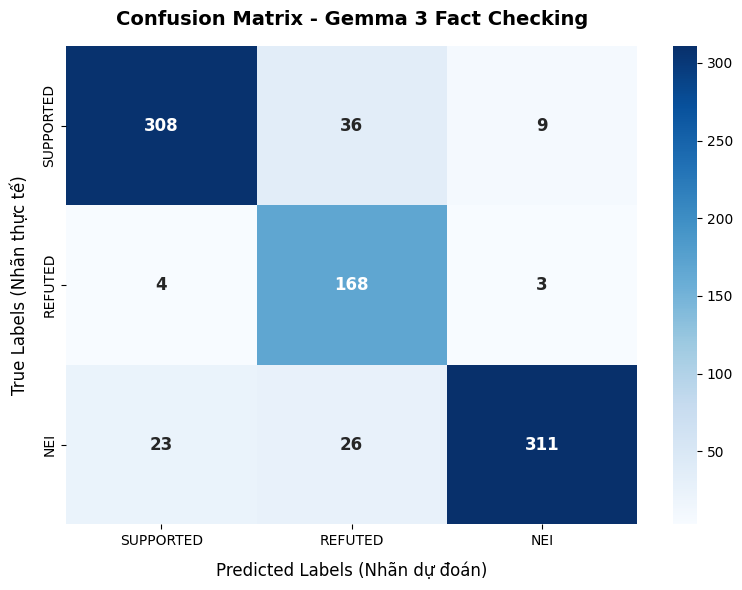

💾 Đã lưu file kết quả tại: output/test_predictions.json
💾 Đã lưu ảnh ma trận tại: output/confusion_matrix.png
🎉 Hoàn tất quá trình suy luận!


In [4]:
import json
import torch
import gc
import os
from unsloth import FastModel
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 0. CHỐNG PHÂN MẢNH VÀ GIẢI PHÓNG BỘ NHỚ ĐỆM GPU
# ============================================================
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# ============================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & THAM SỐ
# ============================================================
CHECKPOINT_DIR = "output/gemma_fact_checking_lora"  
TEST_PATH      = "dataset/test.json"  # Đảm bảo đường dẫn này chính xác

MAX_SEQ_LENGTH = 1536
MAX_NEW_TOKENS = 8
BATCH_SIZE     = 16  # Chạy lô 16 mẫu song song trên GPU để tối ưu tốc độ
LABEL_LIST     = ["SUPPORTED", "REFUTED", "NEI"]

INSTRUCTION = (
    "Bạn là một trợ lý AI kiểm chứng thông tin chuẩn xác. "
    "Hãy đọc các đoạn văn bối cảnh và đưa ra nhãn phân loại cho câu khẳng định. "
    "Chỉ trả về đúng một từ duy nhất, không giải thích, không dấu câu: "
    "SUPPORTED, REFUTED, hoặc NEI."
)

# ============================================================
# 2. LOAD MODEL VÀ TOKENIZER TỪ CHECKPOINT
# ============================================================
print(f"📦 Đang nạp model và bộ mã hóa từ checkpoint: {CHECKPOINT_DIR}...")

model, tokenizer = FastModel.from_pretrained(
    model_name     = CHECKPOINT_DIR,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,
    device_map     = "cuda:0",
)

# Chuyển sang chế độ chuyên dụng phục vụ suy luận nhanh của Unsloth
FastModel.for_inference(model)

# Cấu hình đệm (Padding) bắt buộc để sinh từ theo lô trên GPU
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # Bắt buộc phải là left-padding khi generate hàng loạt

# ============================================================
# 3. ĐỊNH NGHĨA HÀM TIỀN XỬ LÝ DỮ LIỆU
# ============================================================
def build_user_message(claim: str, contexts: list) -> str:
    ctx_text = "\n".join([f"Đoạn văn {i+1}: {c}" for i, c in enumerate(contexts)])
    return (
        f"{INSTRUCTION}\n\n"
        f"[Bối cảnh]:\n{ctx_text}\n\n"
        f"[Khẳng định]: {claim}\n\n"
        f"[Nhãn phân loại]:"
    )

# ============================================================
# 4. ĐỌC DỮ LIỆU TẬP TEST
# ============================================================
print(f"📂 Đang nạp dữ liệu kiểm thử từ: {TEST_PATH}...")
with open(TEST_PATH, "r", encoding="utf-8") as f:
    test_raw = json.load(f)

formatted_prompts = []
y_true = []

# Chuẩn bị dữ liệu và ép cấu hình chuẩn cấu trúc Gemma-3
for sample in test_raw:
    y_true.append(sample["label"].strip().upper())
    prompt_text = build_user_message(sample["claim"], sample["contexts"])
    
    # Định dạng chuẩn cấu trúc đa phương thức của Gemma-3 nhằm tránh lỗi TypeError
    messages = [{"role": "user", "content": [{"type": "text", "text": prompt_text}]}]
    formatted_prompts.append(messages)

# ============================================================
# 5. BẮT ĐẦU CHẠY BATCH INFERENCE TRÊN GPU
# ============================================================
print(f"🏋️ Bắt đầu Inference song song trên GPU (Batch Size = {BATCH_SIZE})...")
y_pred = []

for i in tqdm(range(0, len(formatted_prompts), BATCH_SIZE), desc="Inference"):
    batch_messages = formatted_prompts[i : i + BATCH_SIZE]
    
    # Mã hóa hàng loạt (Batch tokenization)
    inputs = tokenizer.apply_chat_template(
        batch_messages,
        tokenize=True,
        add_generation_prompt=True,
        padding=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens = MAX_NEW_TOKENS,
            do_sample      = False,
            pad_token_id   = tokenizer.eos_token_id,
        )

    # Cắt lấy phần văn bản được sinh mới phía sau Prompt đầu vào
    input_length = inputs["input_ids"].shape[1]
    generated_outputs = output_ids[:, input_length:]
    decoded_batch = tokenizer.batch_decode(generated_outputs, skip_special_tokens=True)
    
    # Hợp thức hóa và chuẩn hóa nhãn đầu ra
    for text in decoded_batch:
        clean_text = text.strip().upper()
        matched_label = "NEI"
        for label in LABEL_LIST:
            if label in clean_text:
                matched_label = label
                break
        y_pred.append(matched_label)

# ============================================================
# 6. ĐÁNH GIÁ, IN BÁO CÁO VÀ VẼ CONFUSION MATRIX
# ============================================================
print("\n" + "="*60)
accuracy    = accuracy_score(y_true, y_pred)
f1_macro    = f1_score(y_true, y_pred, average="macro",    labels=LABEL_LIST, zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", labels=LABEL_LIST, zero_division=0)

print(f"Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro    : {f1_macro:.4f}")
print(f"F1 Weighted : {f1_weighted:.4f}\n")
print("Báo cáo chi tiết phân loại:")
print(classification_report(y_true, y_pred, labels=LABEL_LIST, zero_division=0))

# --- ĐOẠN BỔ SUNG: TÍNH TOÁN VÀ PLOT CONFUSION MATRIX ---
print("📊 Đang vẽ ma trận nhầm lẫn (Confusion Matrix)...")
cm = confusion_matrix(y_true, y_pred, labels=LABEL_LIST)

plt.figure(figsize=(8, 6))
# Sử dụng heatmap của seaborn để biểu diễn ma trận trực quan
sns.heatmap(
    cm, 
    annot=True,              # Hiện số lượng mẫu cụ thể vào từng ô
    fmt="d",                 # Định dạng số nguyên (integer)
    cmap="Blues",            # Tông màu xanh chuyển từ nhạt sang đậm
    xticklabels=LABEL_LIST,  # Nhãn trục X (Dự đoán)
    yticklabels=LABEL_LIST,  # Nhãn trục Y (Thực tế)
    annot_kws={"size": 12, "weight": "bold"} # Định dạng chữ số trong ô
)

plt.title("Confusion Matrix - Gemma 3 Fact Checking", fontsize=14, pad=15, weight="bold")
plt.xlabel("Predicted Labels (Nhãn dự đoán)", fontsize=12, labelpad=10)
plt.ylabel("True Labels (Nhãn thực tế)", fontsize=12, labelpad=10)
plt.tight_layout()

# Tạo thư mục output nếu chưa có và lưu ảnh ma trận nhầm lẫn
os.makedirs("output", exist_ok=True)
plt.savefig("output/confusion_matrix.png", dpi=300)
plt.show() # In trực tiếp biểu đồ ra màn hình Notebook
# --------------------------------------------------------

# Xuất file kết quả dự đoán chi tiết dạng JSON
results_path = "output/test_predictions.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump([
        {"claim": s["claim"], "true_label": t, "pred_label": p}
        for s, t, p in zip(test_raw, y_true, y_pred)
    ], f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu file kết quả tại: {results_path}")
print("💾 Đã lưu ảnh ma trận tại: output/confusion_matrix.png")
print("🎉 Hoàn tất quá trình suy luận!")